In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/spscientist/students-performance-in-exams/StudentsPerformance.csv")

In [3]:
import matplotlib.pyplot as plt

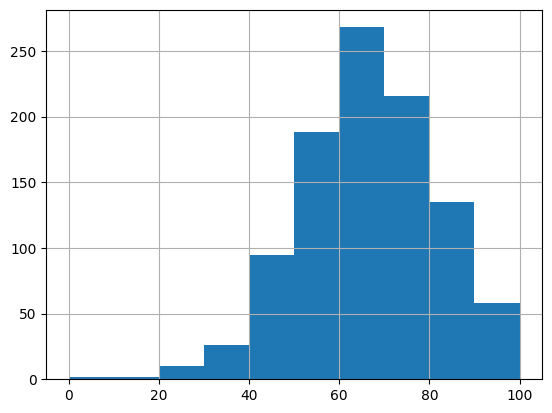

In [4]:
df["math score"].hist()
plt.show()

In [5]:
len(df)

1000

In [6]:
df.shape
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df.dropna()  # simple start

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
...,...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77


In [8]:
df["gender"] = df["gender"].map({"male": 0, "female": 1})

In [9]:
df["gender"]

0      1
1      1
2      1
3      0
4      0
      ..
995    1
996    0
997    1
998    1
999    1
Name: gender, Length: 1000, dtype: int64

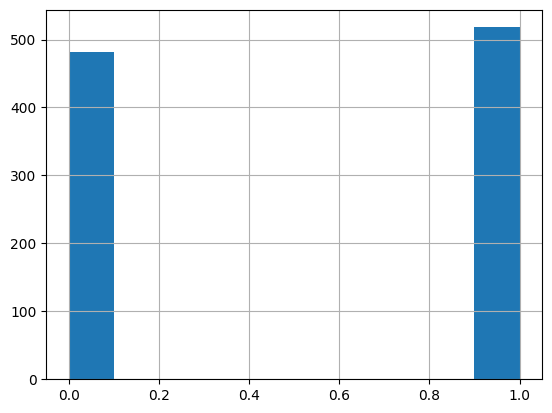

In [10]:
df["gender"].hist()
plt.show()

In [11]:
male_scores = df[df["gender"] == 1]["math score"]

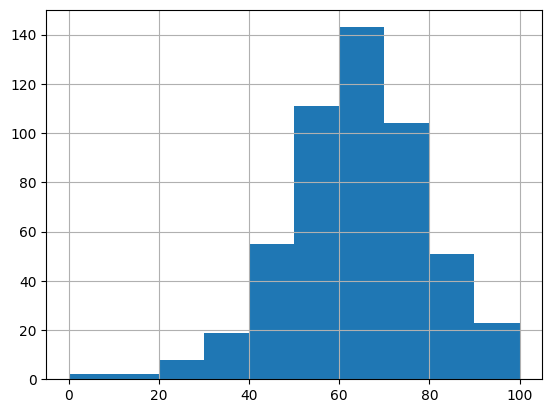

In [12]:
male_scores.hist()
plt.show()

In [13]:
type(df)

pandas.core.frame.DataFrame

In [14]:
df["pass"] = (df["math score"]>=40).astype(int)

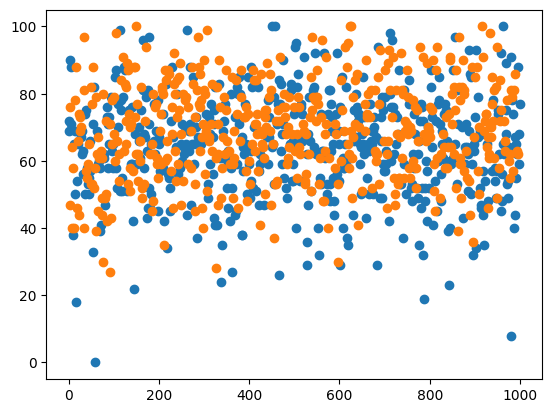

In [15]:
plt.scatter(df[df["gender"]==1].index,df[df["gender"]==1]["math score"],label="male")
plt.scatter(df[df["gender"]==0].index,df[df["gender"]==0]["math score"], label="female")

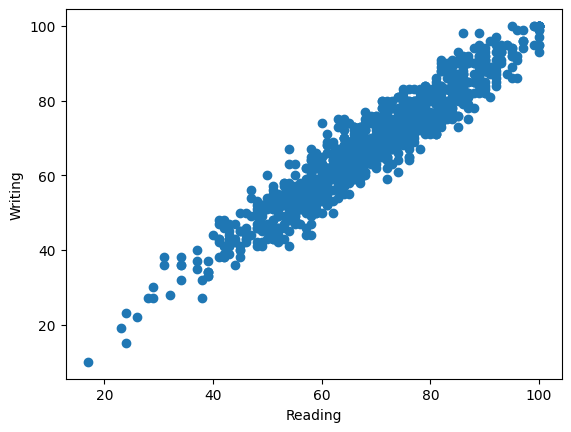

In [16]:
plt.scatter(df["reading score"], df["writing score"])
plt.xlabel("Reading")
plt.ylabel("Writing")
plt.show()

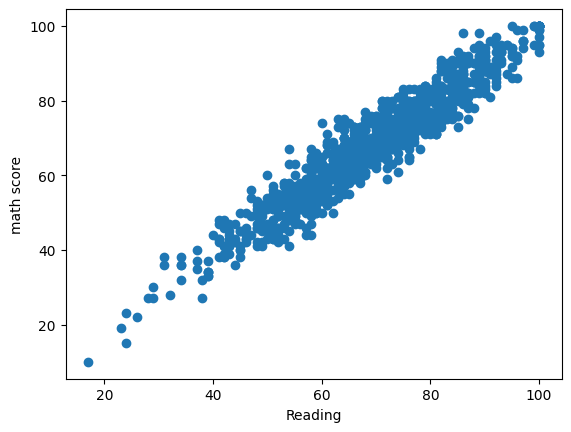

In [17]:
plt.scatter(df["reading score"], df["writing score"])
plt.xlabel("Reading")
plt.ylabel("math score")
plt.show()

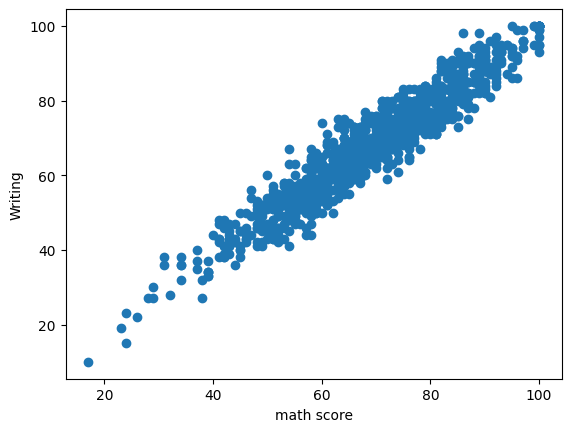

In [18]:
plt.scatter(df["reading score"], df["writing score"])
plt.xlabel("math score")
plt.ylabel("Writing")
plt.show()

In [19]:
X = df[["reading score"]]
y = df["math score"]
X,y

(     reading score
 0               72
 1               90
 2               95
 3               57
 4               78
 ..             ...
 995             99
 996             55
 997             71
 998             78
 999             86
 
 [1000 rows x 1 columns],
 0      72
 1      69
 2      90
 3      47
 4      76
        ..
 995    88
 996    62
 997    59
 998    68
 999    77
 Name: math score, Length: 1000, dtype: int64)

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

predictions
len(predictions)

200

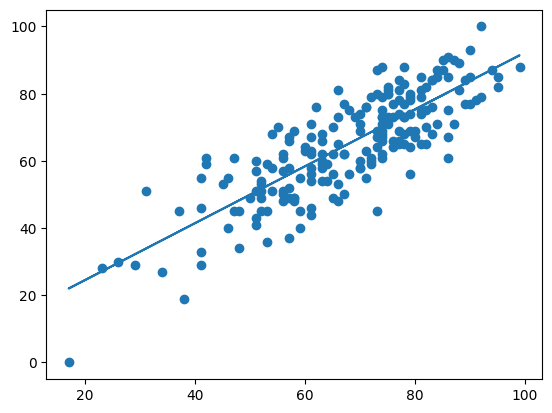

In [21]:
plt.scatter(X_test, y_test)
plt.plot(X_test, predictions)
plt.show()

In [22]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Training samples: 800
Testing samples: 200
Slope: 0.8465291474700295
Intercept: 7.615915147722099


In [23]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)
print(mae)

7.280881770618455


In [24]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, predictions)
print(rmse)

8.818136981676858


In [25]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print("MAE :", mean_absolute_error(y_test, predictions))
print("MSE :", mean_squared_error(y_test, predictions))
print("RMSE:", mean_squared_error(y_test, predictions) ** 0.5)
print("R²  :", r2_score(y_test, predictions))

MAE : 7.280881770618455
MSE : 77.75953982761706
RMSE: 8.818136981676858
R²  : 0.6804469009921283


In [26]:
X = df[["writing score"]]
y = df["math score"]
X,y

(     writing score
 0               74
 1               88
 2               93
 3               44
 4               75
 ..             ...
 995             95
 996             55
 997             65
 998             77
 999             86
 
 [1000 rows x 1 columns],
 0      72
 1      69
 2      90
 3      47
 4      76
        ..
 995    88
 996    62
 997    59
 998    68
 999    77
 Name: math score, Length: 1000, dtype: int64)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

predictions
len(predictions)

200

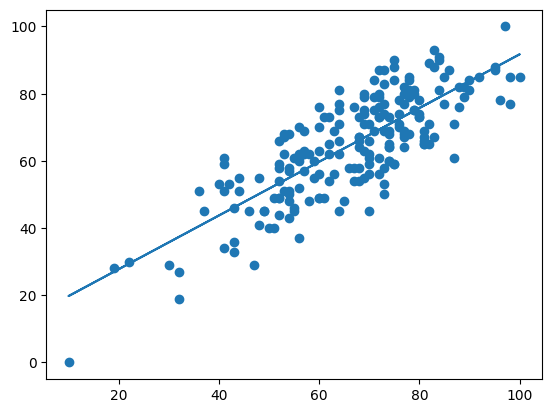

In [28]:
plt.scatter(X_test, y_test)
plt.plot(X_test, predictions)
plt.show()

In [29]:
print("MAE :", mean_absolute_error(y_test, predictions))
print("MSE :", mean_squared_error(y_test, predictions))
print("RMSE:", mean_squared_error(y_test, predictions) ** 0.5)
print("R²  :", r2_score(y_test, predictions))

MAE : 7.835707044474239
MSE : 87.4548424387226
RMSE: 9.351729382243832
R²  : 0.6406040212365882


In [30]:
X = df[["writing score"]]
y = df["reading score"]
X,y

(     writing score
 0               74
 1               88
 2               93
 3               44
 4               75
 ..             ...
 995             95
 996             55
 997             65
 998             77
 999             86
 
 [1000 rows x 1 columns],
 0      72
 1      90
 2      95
 3      57
 4      78
        ..
 995    99
 996    55
 997    71
 998    78
 999    86
 Name: reading score, Length: 1000, dtype: int64)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

predictions
len(predictions)

200

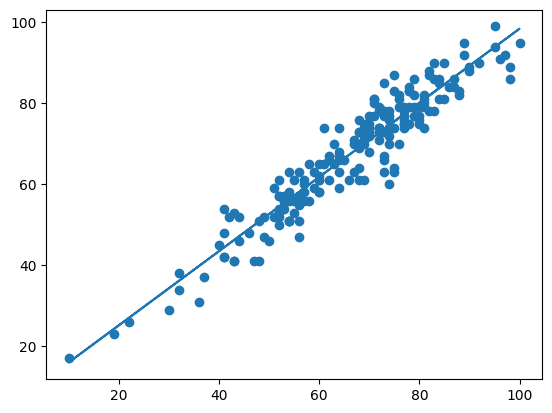

In [32]:
plt.scatter(X_test, y_test)
plt.plot(X_test, predictions)
plt.show()

In [33]:
print("MAE :", mean_absolute_error(y_test, predictions))
print("MSE :", mean_squared_error(y_test, predictions))
print("RMSE:", mean_squared_error(y_test, predictions) ** 0.5)
print("R²  :", r2_score(y_test, predictions))

MAE : 3.707071430056851
MSE : 22.351109420349754
RMSE: 4.727695994916525
R²  : 0.901225573262185
